# Notebook 12 — 2.5D Distillation (Deployment)

**Teacher:** v1 (3D, advanced_v1, det 0.998 / mal 0.986 / Dice 0.857) — dondurulmuş.
**Student:** 2.5D (7 eksenel dilim, hafif 2D CNN, aynı 4 görev) — sıfırdan eğitilir.

**Distillation (online):** her batch'te teacher 3D forward çalışır, student onu taklit eder.
Loss = α·hard (gerçek etiket) + (1−α)·soft (teacher çıktısı).

Amaç: ~5-10× hızlı inference, ~5× az VRAM, 3D performansın %80-90'ı. Teacher MAE'siz (CNN-only, 512).

## 1. Setup

In [6]:
from google.colab import drive
drive.mount('/content/drive')
import os, re, json, gc, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import h5py
from sklearn.metrics import roc_auc_score, r2_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
device: cuda


In [7]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

# kontrol: checkpoint görünüyor mu?
import os
print(os.path.exists(CHECKPOINTS_DIR))
print([f for f in os.listdir(CHECKPOINTS_DIR) if 'advanced_v1' in f and '_best_' in f][:3])

Mounted at /content/drive
True
['advanced_v1_epoch51_best_20260528-094231_full.pth']


## 2. Config

In [8]:
BASE='/content/drive/MyDrive/bitirme'
CHECKPOINTS_DIR=f'{BASE}/Checkpoints_Advanced'
TRAIN_H5=f'{BASE}/Finetune_Patches/patches_train.h5'
VAL_H5  =f'{BASE}/Finetune_Patches/patches_val.h5'
TEST_H5 =f'{BASE}/Finetune_Patches/patches_test.h5'
STUDENT_CKPT=f'{CHECKPOINTS_DIR}/student_2p5d_best.pth'

ROI=64; N_SLICES=7; N_CONCEPTS=8
HU_CLIP=(-1000,1000)
BATCH=32; EPOCHS=40; LR=3e-4
ALPHA=0.5          # hard/soft denge (0.5 = eşit)
TEMP=3.0           # distillation sıcaklığı (det/mal için)
DET_POS_WEIGHT=3.0
LOSS_W={'detection':1.0,'malignancy':1.0,'segmentation':1.0,'concepts':0.3}
print(f'2.5D student: {N_SLICES} dilim | {EPOCHS} epoch | alpha={ALPHA} temp={TEMP}')

2.5D student: 7 dilim | 40 epoch | alpha=0.5 temp=3.0


## 3. Teacher mimarisi (3D, NB9 ile aynı, MAE'siz)

In [9]:
class ResBlock3D(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv1=nn.Conv3d(i,o,3,padding=1,bias=False); self.norm1=nn.InstanceNorm3d(o)
        self.conv2=nn.Conv3d(o,o,3,padding=1,bias=False); self.norm2=nn.InstanceNorm3d(o)
        self.act=nn.LeakyReLU(0.1,inplace=True); self.skip=nn.Conv3d(i,o,1,bias=False) if i!=o else nn.Identity()
    def forward(self,x):
        idt=self.skip(x); out=self.act(self.norm1(self.conv1(x))); out=self.norm2(self.conv2(out)); return self.act(out+idt)
class UNet3D(nn.Module):
    def __init__(self,in_channels=1,base=32):
        super().__init__()
        self.stem=ResBlock3D(in_channels,base)
        self.down1=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base,base*2))
        self.down2=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base*2,base*4))
        self.down3=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base*4,base*8))
        self.bottom=nn.Sequential(nn.MaxPool3d(2),ResBlock3D(base*8,base*16))
        self.global_pool=nn.AdaptiveAvgPool3d(1)
        self.up4=nn.ConvTranspose3d(base*16,base*8,2,2); self.dec4=ResBlock3D(base*16,base*8)
        self.up3=nn.ConvTranspose3d(base*8,base*4,2,2);  self.dec3=ResBlock3D(base*8,base*4)
        self.up2=nn.ConvTranspose3d(base*4,base*2,2,2);  self.dec2=ResBlock3D(base*4,base*2)
        self.up1=nn.ConvTranspose3d(base*2,base,2,2);    self.dec1=ResBlock3D(base*2,base)
        self.final=nn.Conv3d(base,1,1); self.out_dim=base*16
    def forward(self,x):
        s0=self.stem(x); s1=self.down1(s0); s2=self.down2(s1); s3=self.down3(s2); b=self.bottom(s3)
        gf=self.global_pool(b).flatten(1)
        u4=self.up4(b); d4=self.dec4(torch.cat([u4,s3],1)); u3=self.up3(d4); d3=self.dec3(torch.cat([u3,s2],1))
        u2=self.up2(d3); d2=self.dec2(torch.cat([u2,s1],1)); u1=self.up1(d2); d1=self.dec1(torch.cat([u1,s0],1))
        return gf, self.final(d1)
class TeacherCBM(nn.Module):
    def __init__(self,n_concepts=8,head_dropout=0.1):
        super().__init__()
        self.cnn=UNet3D(1,32); cd=self.cnn.out_dim
        self.detection_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(head_dropout),nn.Linear(256,2))
        self.concept_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(0.3),nn.Linear(256,n_concepts))
        self.malignancy_head=nn.Linear(n_concepts,2)
    def forward(self,x):
        gf,seg=self.cnn(x); c=self.concept_head(gf)
        return {'detection':self.detection_head(gf),'concepts':c,'malignancy':self.malignancy_head(c),'segmentation':seg}
print('Teacher mimari OK')

Teacher mimari OK


## 4. Student mimarisi (2.5D, hafif 2D CNN, aynı 4 head)

Girdi: (B, N_SLICES, 64, 64). 2D U-Net benzeri; segmentasyon çıktısı (B,1,64,64) orta dilim.

In [10]:
class ResBlock2D(nn.Module):
    def __init__(self,i,o):
        super().__init__()
        self.conv1=nn.Conv2d(i,o,3,padding=1,bias=False); self.norm1=nn.InstanceNorm2d(o)
        self.conv2=nn.Conv2d(o,o,3,padding=1,bias=False); self.norm2=nn.InstanceNorm2d(o)
        self.act=nn.LeakyReLU(0.1,inplace=True); self.skip=nn.Conv2d(i,o,1,bias=False) if i!=o else nn.Identity()
    def forward(self,x):
        idt=self.skip(x); out=self.act(self.norm1(self.conv1(x))); out=self.norm2(self.conv2(out)); return self.act(out+idt)
class UNet2D(nn.Module):
    def __init__(self,in_channels,base=24):
        super().__init__()
        self.stem=ResBlock2D(in_channels,base)
        self.down1=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base,base*2))
        self.down2=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base*2,base*4))
        self.down3=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base*4,base*8))
        self.bottom=nn.Sequential(nn.MaxPool2d(2),ResBlock2D(base*8,base*16))
        self.global_pool=nn.AdaptiveAvgPool2d(1)
        self.up4=nn.ConvTranspose2d(base*16,base*8,2,2); self.dec4=ResBlock2D(base*16,base*8)
        self.up3=nn.ConvTranspose2d(base*8,base*4,2,2);  self.dec3=ResBlock2D(base*8,base*4)
        self.up2=nn.ConvTranspose2d(base*4,base*2,2,2);  self.dec2=ResBlock2D(base*4,base*2)
        self.up1=nn.ConvTranspose2d(base*2,base,2,2);    self.dec1=ResBlock2D(base*2,base)
        self.final=nn.Conv2d(base,1,1); self.out_dim=base*16
    def forward(self,x):
        s0=self.stem(x); s1=self.down1(s0); s2=self.down2(s1); s3=self.down3(s2); b=self.bottom(s3)
        gf=self.global_pool(b).flatten(1)
        u4=self.up4(b); d4=self.dec4(torch.cat([u4,s3],1)); u3=self.up3(d4); d3=self.dec3(torch.cat([u3,s2],1))
        u2=self.up2(d3); d2=self.dec2(torch.cat([u2,s1],1)); u1=self.up1(d2); d1=self.dec1(torch.cat([u1,s0],1))
        return gf, self.final(d1)
class Student2p5D(nn.Module):
    def __init__(self,n_slices=7,n_concepts=8,head_dropout=0.1):
        super().__init__()
        self.cnn=UNet2D(n_slices,base=24); cd=self.cnn.out_dim
        self.detection_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(head_dropout),nn.Linear(256,2))
        self.concept_head=nn.Sequential(nn.LayerNorm(cd),nn.Linear(cd,256),nn.GELU(),nn.Dropout(0.3),nn.Linear(256,n_concepts))
        self.malignancy_head=nn.Linear(n_concepts,2)
    def forward(self,x):
        gf,seg=self.cnn(x); c=self.concept_head(gf)
        return {'detection':self.detection_head(gf),'concepts':c,'malignancy':self.malignancy_head(c),'segmentation':seg}
_s=Student2p5D(N_SLICES,N_CONCEPTS)
print('Student param: %.2fM'%(sum(p.numel() for p in _s.parameters())/1e6))
_t=TeacherCBM(); print('Teacher param: %.2fM'%(sum(p.numel() for p in _t.parameters())/1e6)); del _s,_t

Student param: 4.76M
Teacher param: 23.19M


## 5. Teacher'ı yükle + dondur

In [11]:
teacher=TeacherCBM(n_concepts=N_CONCEPTS).to(device)
def sk(n):
    m=re.match(r'advanced_v1_epoch(\d+)_best_.*_full\.pth$',n); return int(m.group(1)) if m else -1
bf=sorted([f for f in os.listdir(CHECKPOINTS_DIR) if 'advanced_v1' in f and '_best_' in f and f.endswith('_full.pth')],key=sk)
assert bf,'v1 best yok'
ck=torch.load(os.path.join(CHECKPOINTS_DIR,bf[-1]),map_location=device,weights_only=False)
mi,un=teacher.load_state_dict(ck['model_state_dict'],strict=False)
teacher.eval()
for p in teacher.parameters(): p.requires_grad=False
print('Teacher yüklendi:',bf[-1],'| eksik',len(mi),'beklenmedik',len(un))

Teacher yüklendi: advanced_v1_epoch51_best_20260528-094231_full.pth | eksik 0 beklenmedik 0


## 6. Dataset — 3D patch (teacher için) + 2.5D dilimler (student için)

In [12]:
class DistillDataset(Dataset):
    """Her örnek: 3D patch (teacher) + ortadaki N_SLICES dilim (student) + etiketler."""
    def __init__(self, h5_path, n_slices=7, augment=False):
        self.h5_path=h5_path; self.n_slices=n_slices; self.augment=augment; self.h5=None
        with h5py.File(h5_path,'r') as f: self.N=f['patches'].shape[0]
    def __len__(self): return self.N
    def _ensure(self):
        if self.h5 is None: self.h5=h5py.File(self.h5_path,'r')
    def __getitem__(self, idx):
        self._ensure()
        patch=self.h5['patches'][idx].astype(np.float32)
        patch=np.clip(patch,HU_CLIP[0],HU_CLIP[1]); patch=(patch-HU_CLIP[0])/(HU_CLIP[1]-HU_CLIP[0])
        mask=self.h5['masks'][idx].astype(np.float32)
        det=int(self.h5['detection'][idx]); mal=int(self.h5['malignancy'][idx]); seg=float(self.h5['seg_loss_mask'][idx])
        con=self.h5['concepts'][idx].astype(np.float32)
        if self.augment:
            for ax in [0,1,2]:
                if np.random.rand()<0.5: patch=np.flip(patch,ax).copy(); mask=np.flip(mask,ax).copy()
        # 2.5D: ortadaki n_slices eksenel dilim (z ekseni=0)
        c=ROI//2; h=self.n_slices//2
        sl=patch[c-h:c+h+1]            # (n_slices,64,64)
        mid_mask=mask[c]               # student seg hedefi: orta dilim (1,64,64)
        return {
            'patch3d':torch.from_numpy(patch[None]),       # (1,64,64,64) teacher
            'slices': torch.from_numpy(sl),                # (n_slices,64,64) student
            'mask3d': torch.from_numpy(mask[None]),        # (1,64,64,64) teacher seg hedef
            'mask2d': torch.from_numpy(mid_mask[None]),    # (1,64,64) student seg hedef
            'detection':torch.tensor(det), 'malignancy':torch.tensor(mal),
            'seg_loss_mask':torch.tensor(seg), 'concepts':torch.from_numpy(con)}

train_ds=DistillDataset(TRAIN_H5,N_SLICES,augment=True)
val_ds  =DistillDataset(VAL_H5,N_SLICES,augment=False)
train_loader=DataLoader(train_ds,batch_size=BATCH,shuffle=True,num_workers=2,pin_memory=True,drop_last=True)
val_loader  =DataLoader(val_ds,batch_size=BATCH,shuffle=False,num_workers=2,pin_memory=True)
print('Train:',len(train_ds),'Val:',len(val_ds))

Train: 5870 Val: 1100


## 7. Distillation loss

hard = gerçek etikete CE/Dice/MSE; soft = teacher çıktısına KL (det/mal/concept) + MSE (seg).
Toplam = α·hard + (1−α)·soft, görev ağırlıklarıyla.

In [13]:
def dice_bce(logits,target,smooth=1.0):
    prob=torch.sigmoid(logits)
    inter=(prob*target).sum((1,2,3)); union=prob.sum((1,2,3))+target.sum((1,2,3))
    dice=1-(2*inter+smooth)/(union+smooth)
    bce=F.binary_cross_entropy_with_logits(logits,target,reduction='none').mean((1,2,3))
    return (dice+bce).mean()

def kl_soft(s_logits,t_logits,T):
    return F.kl_div(F.log_softmax(s_logits/T,1),F.softmax(t_logits/T,1),reduction='batchmean')*(T*T)

def distill_loss(s_out,t_out,batch):
    dev=s_out['detection'].device
    det_w=torch.tensor([1.0,DET_POS_WEIGHT],device=dev)
    # --- HARD (gerçek etiket) ---
    h_det=F.cross_entropy(s_out['detection'],batch['detection'].to(dev),weight=det_w)
    mal_t=batch['malignancy'].to(dev); mv=mal_t!=-1
    h_mal=F.cross_entropy(s_out['malignancy'][mv],mal_t[mv]) if mv.any() else torch.tensor(0.,device=dev)
    segm=batch['seg_loss_mask'].to(dev)>0
    if segm.any():
        h_seg=dice_bce(s_out['segmentation'][segm],batch['mask2d'].to(dev)[segm])
    else: h_seg=torch.tensor(0.,device=dev)
    con_t=batch['concepts'].to(dev); cv=con_t[:,0]!=-1.0
    h_con=F.mse_loss(s_out['concepts'][cv],con_t[cv]) if cv.any() else torch.tensor(0.,device=dev)
    hard=LOSS_W['detection']*h_det+LOSS_W['malignancy']*h_mal+LOSS_W['segmentation']*h_seg+LOSS_W['concepts']*h_con
    # --- SOFT (teacher) ---
    s_det=kl_soft(s_out['detection'],t_out['detection'],TEMP)
    s_mal=kl_soft(s_out['malignancy'],t_out['malignancy'],TEMP)
    s_con=F.mse_loss(s_out['concepts'],t_out['concepts'])
    # seg soft: teacher 3D segin orta dilimi hedef
    t_seg_mid=t_out['segmentation'][:,:,ROI//2]   # (B,1,64,64)
    s_seg=F.mse_loss(torch.sigmoid(s_out['segmentation']),torch.sigmoid(t_seg_mid))
    soft=LOSS_W['detection']*s_det+LOSS_W['malignancy']*s_mal+LOSS_W['segmentation']*s_seg+LOSS_W['concepts']*s_con
    total=ALPHA*hard+(1-ALPHA)*soft
    return total,{'hard':hard.item(),'soft':soft.item(),'h_det':h_det.item(),'h_mal':float(h_mal),'h_seg':float(h_seg)}

## 8. Student değerlendirme

In [14]:
@torch.no_grad()
def eval_student(student,loader):
    student.eval()
    dl,dt,ml,mt,dices,cp,ct=[],[],[],[],[],[],[]
    for b in loader:
        sl=b['slices'].to(device)
        with autocast('cuda',dtype=torch.bfloat16): out=student(sl)
        dl.append(torch.softmax(out['detection'].float(),1)[:,1].cpu().numpy()); dt.append(b['detection'].numpy())
        mv=b['malignancy']!=-1
        if mv.any():
            ml.append(torch.softmax(out['malignancy'][mv].float(),1)[:,1].cpu().numpy()); mt.append(b['malignancy'][mv].numpy())
        sm=b['seg_loss_mask']>0
        if sm.any():
            p=(torch.sigmoid(out['segmentation'][sm].float())>0.5).cpu().numpy(); t=b['mask2d'][sm].numpy()
            for i in range(p.shape[0]):
                inter=(p[i]*t[i]).sum(); union=p[i].sum()+t[i].sum(); dices.append((2*inter+1)/(union+1))
        cv=b['concepts'][:,0]!=-1.0
        if cv.any(): cp.append(out['concepts'][cv].float().cpu().numpy()); ct.append(b['concepts'][cv].numpy())
    m={}
    m['det_auc']=roc_auc_score(np.concatenate(dt),np.concatenate(dl))
    m['mal_auc']=roc_auc_score(np.concatenate(mt),np.concatenate(ml)) if ml else float('nan')
    m['dice']=float(np.mean(dices)) if dices else float('nan')
    m['r2']=r2_score(np.concatenate(ct),np.concatenate(cp),multioutput='variance_weighted') if cp else float('nan')
    return m

## 9. Distillation eğitimi

In [15]:
student=Student2p5D(N_SLICES,N_CONCEPTS).to(device)
opt=torch.optim.AdamW(student.parameters(),lr=LR,weight_decay=1e-4)
sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS)
scaler=GradScaler('cuda')
best_mal=0.0; hist=[]

for epoch in range(EPOCHS):
    student.train(); t0=time.time(); run={'total':0,'hard':0,'soft':0}; nb=0
    for b in tqdm(train_loader,desc=f'E{epoch+1}/{EPOCHS}',leave=False):
        p3d=b['patch3d'].to(device); sl=b['slices'].to(device)
        with torch.no_grad(), autocast('cuda',dtype=torch.bfloat16):
            t_out=teacher(p3d)
        opt.zero_grad()
        with autocast('cuda',dtype=torch.bfloat16):
            s_out=student(sl)
            loss,parts=distill_loss(s_out,{k:v.float() for k,v in t_out.items()},b)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        run['total']+=loss.item(); run['hard']+=parts['hard']; run['soft']+=parts['soft']; nb+=1
    sched.step()
    vm=eval_student(student,val_loader)
    dt=(time.time()-t0)/60
    print(f'E{epoch+1}: loss={run["total"]/nb:.3f} (h={run["hard"]/nb:.3f} s={run["soft"]/nb:.3f}) | '
          f'val det={vm["det_auc"]:.4f} mal={vm["mal_auc"]:.4f} dice={vm["dice"]:.4f} r2={vm["r2"]:.3f} | {dt:.1f}dk')
    hist.append({'epoch':epoch+1,**vm})
    if not np.isnan(vm['mal_auc']) and vm['mal_auc']>best_mal:
        best_mal=vm['mal_auc']
        torch.save({'model_state_dict':student.state_dict(),'epoch':epoch+1,'val':vm,'n_slices':N_SLICES},STUDENT_CKPT)
        print(f'   ⭐ yeni best mal_auc={best_mal:.4f} → kaydedildi')
print('\nEğitim bitti. Best val mal_auc:',round(best_mal,4))

E1/40:   0%|          | 0/183 [00:00<?, ?it/s]

/tmp/ipykernel_1140/675439864.py:34: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return total,{'hard':hard.item(),'soft':soft.item(),'h_det':h_det.item(),'h_mal':float(h_mal),'h_seg':float(h_seg)}


E1: loss=1.827 (h=2.659 s=0.994) | val det=0.9649 mal=0.9019 dice=0.7813 r2=-0.923 | 3.5dk
   ⭐ yeni best mal_auc=0.9019 → kaydedildi


E2/40:   0%|          | 0/183 [00:00<?, ?it/s]

E2: loss=1.067 (h=1.485 s=0.649) | val det=0.9786 mal=0.9106 dice=0.8179 r2=-1.073 | 0.5dk
   ⭐ yeni best mal_auc=0.9106 → kaydedildi


...

E38: loss=0.452 (h=0.545 s=0.360) | val det=0.9874 mal=0.9744 dice=0.8561 r2=-0.761 | 0.5dk


E39/40:   0%|          | 0/183 [00:00<?, ?it/s]

E39: loss=0.464 (h=0.565 s=0.363) | val det=0.9877 mal=0.9740 dice=0.8553 r2=-0.801 | 0.5dk


E40/40:   0%|          | 0/183 [00:00<?, ?it/s]

E40: loss=0.451 (h=0.544 s=0.359) | val det=0.9877 mal=0.9740 dice=0.8553 r2=-0.797 | 0.5dk

Eğitim bitti. Best val mal_auc: 0.9809


## 10. Test + teacher karşılaştırması + hız

In [16]:
# en iyi student'ı yükle
ck=torch.load(STUDENT_CKPT,map_location=device,weights_only=False)
student.load_state_dict(ck['model_state_dict']); student.eval()
test_ds=DistillDataset(TEST_H5,N_SLICES,augment=False)
test_loader=DataLoader(test_ds,batch_size=BATCH,shuffle=False,num_workers=2)
sm=eval_student(student,test_loader)
print('='*56); print('  STUDENT (2.5D) TEST:'); print('='*56)
print(f'  det_auc={sm["det_auc"]:.4f} | mal_auc={sm["mal_auc"]:.4f} | dice={sm["dice"]:.4f} | r2={sm["r2"]:.3f}')
print('  Teacher (3D) test referans: det 0.998 | mal 0.986 | dice 0.857')

# hız karşılaştırması
import time as _t
x3=torch.randn(8,1,ROI,ROI,ROI,device=device); x25=torch.randn(8,N_SLICES,ROI,ROI,device=device)
for _ in range(3):
    with torch.no_grad(): teacher(x3); student(x25)
torch.cuda.synchronize() if device.type=='cuda' else None
t0=_t.time()
for _ in range(20):
    with torch.no_grad(): teacher(x3)
torch.cuda.synchronize() if device.type=='cuda' else None; tt=_t.time()-t0
t0=_t.time()
for _ in range(20):
    with torch.no_grad(): student(x25)
torch.cuda.synchronize() if device.type=='cuda' else None; ts=_t.time()-t0
np_t=sum(p.numel() for p in teacher.parameters())/1e6; np_s=sum(p.numel() for p in student.parameters())/1e6
print('\n'+'='*56); print('  HİZ & BOYUT'); print('='*56)
print(f'  Teacher: {tt/20*1000:.1f} ms/batch | {np_t:.2f}M param')
print(f'  Student: {ts/20*1000:.1f} ms/batch | {np_s:.2f}M param')
print(f'  Hızlanma: {tt/ts:.1f}× | Boyut: {np_t/np_s:.1f}× küçük')

  STUDENT (2.5D) TEST:
  det_auc=0.9969 | mal_auc=0.9862 | dice=0.8594 | r2=-0.710
  Teacher (3D) test referans: det 0.998 | mal 0.986 | dice 0.857

  HİZ & BOYUT
  Teacher: 28.6 ms/batch | 23.19M param
  Student: 4.4 ms/batch | 4.76M param
  Hızlanma: 6.5× | Boyut: 4.9× küçük


## 11. Eğitim eğrileri

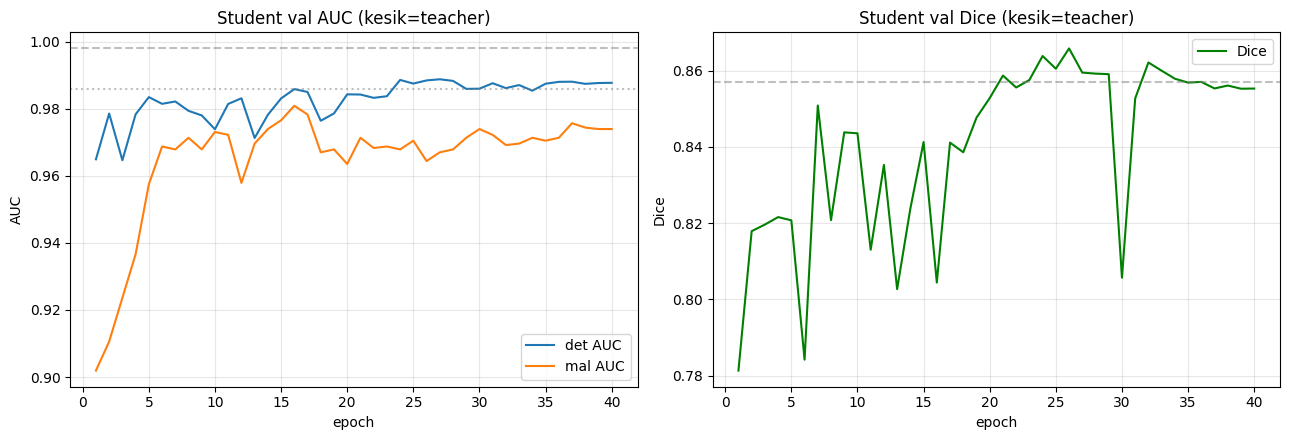

In [17]:
ep=[h['epoch'] for h in hist]
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
ax[0].plot(ep,[h['det_auc'] for h in hist],label='det AUC')
ax[0].plot(ep,[h['mal_auc'] for h in hist],label='mal AUC')
ax[0].axhline(0.998,ls='--',c='gray',alpha=0.5); ax[0].axhline(0.986,ls=':',c='gray',alpha=0.5)
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('AUC'); ax[0].set_title('Student val AUC (kesik=teacher)'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep,[h['dice'] for h in hist],c='green',label='Dice')
ax[1].axhline(0.857,ls='--',c='gray',alpha=0.5)
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('Dice'); ax[1].set_title('Student val Dice (kesik=teacher)'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/content/student_curves.png',dpi=120); plt.show()

In [18]:
import os, shutil

# 1) Student checkpoint nerede, sağlam mı?
print("STUDENT_CKPT yolu:", STUDENT_CKPT)
if os.path.exists(STUDENT_CKPT):
    sz = os.path.getsize(STUDENT_CKPT)/1e6
    print(f"✅ Mevcut: {sz:.1f} MB")
else:
    print("⚠️ Bulunamadı! Hafızadaki student'ı yeniden kaydedelim:")

# 2) Her ihtimale karşı hafızadaki best student'ı LOCAL'e taze kaydet
#    (Drive'a yazılmış olan zaten best; bu local güvence kopyası)
LOCAL_CKPT = '/content/student_2p5d_best_GUVENCE.pth'
# eğer STUDENT_CKPT Drive'daysa ve okunabiliyorsa onu kopyala, değilse hafızadan kaydet
try:
    if os.path.exists(STUDENT_CKPT):
        shutil.copy(STUDENT_CKPT, LOCAL_CKPT)
        print(f"✅ Drive→Local kopyalandı: {LOCAL_CKPT}")
    else:
        raise FileNotFoundError
except Exception as e:
    # hafızadaki student state'i kaydet (en son best değil ama en son epoch — yine de iyi)
    torch.save({'model_state_dict':student.state_dict(),'n_slices':N_SLICES,
                'note':'guvence_son_epoch'}, LOCAL_CKPT)
    print(f"✅ Hafızadan local'e kaydedildi: {LOCAL_CKPT}")

print(f"\nLocal güvence boyutu: {os.path.getsize(LOCAL_CKPT)/1e6:.1f} MB")

STUDENT_CKPT yolu: /content/drive/MyDrive/bitirme/Checkpoints_Advanced/student_2p5d_best.pth
✅ Mevcut: 19.1 MB
✅ Drive→Local kopyalandı: /content/student_2p5d_best_GUVENCE.pth

Local güvence boyutu: 19.1 MB


In [19]:
from google.colab import files
files.download('/content/student_2p5d_best_GUVENCE.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Drive bağlı mı kontrol + yaz
try:
    drive_path = f'{CHECKPOINTS_DIR}/student_2p5d_best.pth'
    shutil.copy('/content/student_2p5d_best_GUVENCE.pth', drive_path)
    print(f"✅ Drive'a da yazıldı: {drive_path}")
    print(f"   doğrulama: {os.path.getsize(drive_path)/1e6:.1f} MB")
except Exception as e:
    print(f"⚠️ Drive'a yazılamadı ({e}) — local indirme yeterli, sorun değil")

✅ Drive'a da yazıldı: /content/drive/MyDrive/bitirme/Checkpoints_Advanced/student_2p5d_best.pth
   doğrulama: 19.1 MB
